### Construct a 2-D Inglehart-welzel cultural space and check country distribution
- Fit one model for each dimension
- Apply the model to find the mapping of WVS (country-average) and LLM representations in this space 
- Compare the differences between their distribution in the cultural spaces

In [1]:
import pickle
import pandas as pd 
import geopandas as gpd
import scipy.stats as stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr
from adjustText import adjust_text

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

### Load data

In [ ]:
# get the selected survey items
df_avg = pd.read_csv("./data/wvs7_country_avg.csv").set_index('Country')
items = list(df_avg.columns) # select the same items for the following dataframes
all_countries = list(df_avg.index)
print(df_avg.shape)

(66, 117)


In [ ]:
# LLM country representation
# make sure rows/countries and columns/items have consistent orders
df_gpt = pd.read_csv("./data/gpt_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries+['model']]
df_claude = pd.read_csv("./data/claude_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries+['model']]
df_deepseek = pd.read_csv("./data/deepseek_scaled.csv")[['Country']+items].set_index('Country').loc[all_countries+['model']]

df_gpt.shape, df_claude.shape, df_deepseek.shape

((67, 117), (67, 117), (67, 117))

In [ ]:
# load wave-7 scaled data of individual responses
df_wvs = pd.read_csv("./data/wvs7_scaled.csv")[['Country',"TradAgg", "SurvSAgg"] + items].set_index('Country')
df_wvs.shape

(97220, 119)

In [5]:
df_wvs
# be careful of the NaN values

,TradAgg,SurvSAgg,A001,A002,A003,A004,A005,A006,A008,A009,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
Country,,,,,,,,,,,,,,,,,,,,,
Andorra,NaN,NaN,1.0,1.000000,1.000000,0.333333,1.000000,0.000000,1.000000,0.50,...,1.000000,0.666667,0.666667,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.000000
Andorra,-0.759811,4.294714,1.0,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.00,...,1.000000,0.666667,0.666667,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
Andorra,1.639513,1.387292,1.0,0.666667,0.666667,0.666667,0.333333,0.333333,0.666667,1.00,...,1.000000,0.333333,0.000000,0.000000,0.000000,0.000000,0.333333,1.0,1.0,0.000000
Andorra,NaN,NaN,1.0,1.000000,1.000000,0.000000,0.666667,0.000000,0.666667,0.75,...,0.666667,0.666667,0.666667,0.000000,0.000000,0.000000,0.000000,1.0,1.0,0.000000
Andorra,NaN,NaN,1.0,1.000000,1.000000,0.333333,1.000000,0.333333,0.666667,0.75,...,0.666667,0.666667,0.666667,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zimbabwe,-1.346378,-1.299450,1.0,0.333333,1.000000,1.000000,1.000000,0.666667,0.666667,1.00,...,1.000000,0.666667,0.666667,0.333333,0.333333,0.666667,1.000000,0.0,0.0,0.333333
Zimbabwe,0.354463,-0.767520,1.0,1.000000,0.666667,1.000000,1.000000,1.000000,0.666667,1.00,...,0.000000,1.000000,1.000000,0.000000,1.000000,0.666667,0.666667,1.0,0.0,0.000000
Zimbabwe,-0.802691,-1.637090,1.0,0.333333,0.666667,0.666667,0.666667,0.666667,0.333333,0.50,...,0.666667,1.000000,1.000000,0.666667,0.666667,0.666667,0.666667,1.0,0.0,0.000000


In [6]:
# LLM country representation
llm_name = 'GPT' # GPT, Claude, DeepSeek
df_llm = df_gpt # df_gpt, df_claude, df_deepseek

### Fit one model for each IGW dimension
- Remove samples where the IGW dimension is NaN
- Fit a linear regression model for each dimension
- Evaluate with 5-fold cross validation 

In [7]:
from sklearn.linear_model import LinearRegression

# remove samples where TradAgg is NaN
df_trad = df_wvs.dropna(subset=["TradAgg"])

X_trad = df_trad[items]
y_trad = df_trad["TradAgg"]

trad_model = LinearRegression()
trad_cv_scores = cross_val_score(trad_model, X_trad, y_trad, cv=5)

print("R^2 per fold:", trad_cv_scores.round(3))
print("Mean R^2: %.3f (+/- %.3f)" % (trad_cv_scores.mean(), trad_cv_scores.std()))

# fit on all available (non-NaN) data for later use
trad_model.fit(X_trad, y_trad)

R^2 per fold: [0.773 0.822 0.793 0.778 0.732]
Mean R^2: 0.780 (+/- 0.029)


LinearRegression()

In [8]:
# (item, coef) pairs, sorted by coefficient value
trad_coefs = pd.Series(trad_model.coef_.round(3), index=items).sort_values()

top10_neg = trad_coefs.head(10)
top10_pos = trad_coefs.tail(10).sort_values(ascending=False)

print("Top-10 negative coefficients:")
print(top10_neg)
print("\nTop-10 positive coefficients:")
print(top10_pos)

Top-10 negative coefficients:
A008      -2.857
E018      -1.363
A006      -0.681
F028B     -0.535
D054      -0.311
E069_01   -0.245
F202      -0.231
A165      -0.215
E124      -0.210
E235      -0.179
dtype: float64

Top-10 positive coefficients:
F120         1.052
F123         0.220
E069_05      0.152
F122         0.133
E026         0.128
G007_36_B    0.113
A004         0.110
E069_08      0.099
E034         0.096
H008_09      0.083
dtype: float64


In [9]:
# remove samples where TradAgg is NaN
df_survs = df_wvs.dropna(subset=["SurvSAgg"])

X_survs = df_survs[items]
y_survs = df_survs["SurvSAgg"]

survs_model = LinearRegression()
survs_cv_scores = cross_val_score(survs_model, X_survs, y_survs, cv=5)

print("R^2 per fold:", survs_cv_scores.round(3))
print("Mean R^2: %.3f (+/- %.3f)" % (survs_cv_scores.mean(), survs_cv_scores.std()))

# fit on all available (non-NaN) data for later use
survs_model.fit(X_survs, y_survs)

R^2 per fold: [0.845 0.845 0.75  0.828 0.811]
Mean R^2: 0.816 (+/- 0.035)


LinearRegression()

In [10]:
# (item, coef) pairs, sorted by coefficient value
trad_coefs = pd.Series(survs_model.coef_.round(3), index=items).sort_values()

top10_neg = trad_coefs.head(10)
top10_pos = trad_coefs.tail(10).sort_values(ascending=False)

print("Top-10 negative coefficients:")
print(top10_neg)
print("\nTop-10 positive coefficients:")
print(top10_pos)

Top-10 negative coefficients:
A006      -0.185
F202      -0.168
F114C     -0.132
D059      -0.124
C001_01   -0.120
C002_01   -0.118
D026_05   -0.113
C038      -0.110
D026_03   -0.103
D078      -0.096
dtype: float64

Top-10 positive coefficients:
A008    3.126
E025    1.421
F120    1.366
A165    1.021
F121    0.286
F123    0.226
E018    0.216
F122    0.209
F117    0.152
E124    0.152
dtype: float64


- Apply the fitted models to predict IGW scores of WVS (country-average) and LLM representations in this space 

In [11]:
df_avg["TradAgg"] = trad_model.predict(df_avg[items])
df_avg["SurvsAgg"] = survs_model.predict(df_avg[items])

df_llm["TradAgg"] = trad_model.predict(df_llm[items])
df_llm["SurvsAgg"] = survs_model.predict(df_llm[items])

### Spatio distribution in 2D IGW space
- x-axis: survival vs self-expression
- y-axis: traditional vs secular-rational

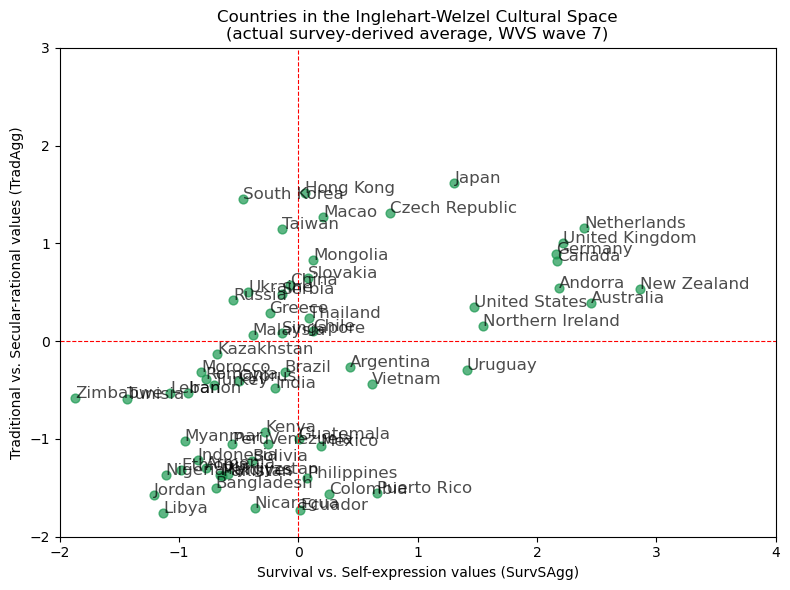

In [ ]:
# Average of actual (survey-derived) IGW scores per country, after dropping NaNs
df_wvs_avg = (
    df_wvs.dropna(subset=["TradAgg", "SurvSAgg"])
    .groupby("Country")[["TradAgg", "SurvSAgg"]]
    .mean()
)

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(df_wvs_avg["SurvSAgg"], df_wvs_avg["TradAgg"], color="#1a9850", alpha=0.7, s=40)
for country, row in df_wvs_avg.iterrows():
    ax.annotate(country, (row["SurvSAgg"], row["TradAgg"]), fontsize=12, alpha=0.7)

ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
ax.axvline(0, color="red", linewidth=0.8, linestyle="--")
ax.set_xlim(-2,4)
ax.set_ylim(-2,3)
# ax.set_xlabel("Survival vs. Self-expression values (SurvSAgg)")
# ax.set_ylabel("Traditional vs. Secular-rational values (TradAgg)")
ax.set_xlabel("Emancipative values (SurvSAgg)")
ax.set_ylabel("Secular values (TradAgg)")
ax.set_title("Countries in the Inglehart-Welzel Cultural Space\n(actual survey-derived average, WVS wave 7)")
plt.tight_layout()
plt.show()

In [ ]:
def visualize_human():
    """Country distribution under human average"""
    # adjust text to avoid overlap
    forced_human = {
        "Japan": (0, 0.1), "Macao": (0.3, 0), "Mongolia": (-0.4, 0), "Slovakia": (0.4, 0),
        "Taiwan": (-0.3, 0), "Greece": (-0.3, 0),"Serbia": (0.3, 0), "China": (0.3, 0),
        "Ukraine": (-0.5, -0.1), "Russia": (-0.5, -0.05),"Singapore": (-0.5, -0.05), "Chile": (0, +0.1),
        "Argentina": (0, 0), "Armenia": (-0.1, 0.1),
        "Andorra": (0.4, -0.1), "United States": (0.7, 0), "Northern Ireland": (0.7, -0.1),
        "Uruguay": (0.5, 0), "Argentina": (0.5, 0), "Vietnam": (0.5, 0), "Brazil": (0.4, 0), "India": (0.4, 0),
        "Cyprus": (-0.5, 0),"Iran": (-0.8, 0), "Tunisia": (-0.3, 0),"Egypt": (-0.3, 0),
        "Myanmar": (-0.5, -0.1),"Kenya": (0.5, 0),"Uzbekistan": (0.5, 0),"Libya": (0, -0.1),
        "Jordan": (-0.5, -0.2), "Puerto Rico": (1.0, 0), "Nicaragua": (-0, +0.1), "Guatemala": (0.5, +0.1), 
        "Mexico": (0.5, 0), "Turkey": (-0.3, -0.1), "Iraq": (-0.5, 0.1), "Romania": (-0.7, 0),
        "Peru": (0.0, 0.1), "Venezuela": (-0.1, -0.0),"Bolivia": (-0.4, 0.05), "Bangladesh": (0.7, -0.4), 
        "Nigeria": (-0.2, -0.1), "Colombia": (0.5, 0),  "Ecuador": (0.5, 0),  "Tajikistan": (0.5, -0.3),
        "Kyrgyzstan": (0, -0.2), "Maldives": (0.1, 0.2), "Pakistan": (0, -0.1), "Indonesia": (-0.7, -0.1),
        "Ethiopia": (-0.3, 0), "Australia": (0.5, 0), "Canada": (-0.3, 0), "Philippines": (0.7, -0.3),  
        "Zimbabwe": (-0.7, 0),"Germany": (-0.5, 0.1), "Kazakhstan": (-0.5, 0),"Lebanon": (0, 0),
        "Malaysia": (0, 0),"Morocco": (0, 0),  "Netherlands": (0.0, 0.1),"New Zealand": (0.6, 0),  
        "South Korea": (-0.5, 0),  "Thailand": (-0.5, 0), "United Kingdom": (0.7, 0),
    }

    color = "#4575b4"
    group = df_avg[["TradAgg", "SurvsAgg"]].reset_index()

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    # scatter
    ax.scatter(group["SurvsAgg"], group["TradAgg"], color=color, alpha=0.7, s=40, zorder=3)

    # country labels
    texts = []
    for _, row in group.iterrows():
        t = ax.text(row["SurvsAgg"], row["TradAgg"], row["Country"], fontsize=15, alpha=0.85)
        texts.append(t)

    adjust_text(texts, ax=ax,
                x=group["SurvsAgg"].values, y=group["TradAgg"].values,
                expand=(1.3, 1.5))

    # apply forced absolute positions
    for t, (_, row) in zip(texts, group.iterrows()):
        ctry = row["Country"]
        if ctry in forced_human:
            fdx, fdy = forced_human[ctry]
            t.set_position((row["SurvsAgg"] + fdx, row["TradAgg"] + fdy))

    # arrows for far-displaced labels
    arrow_threshold = 2
    for t, (_, row) in zip(texts, group.iterrows()):
        tx, ty = t.get_position()
        px, py = row["SurvsAgg"], row["TradAgg"]
        if ((tx - px)**2 + (ty - py)**2) ** 0.5 > arrow_threshold:
            ax.annotate("", xy=(px, py), xytext=(tx, ty),
                        arrowprops=dict(arrowstyle="->", color="gray", lw=0.6),
                        zorder=2)

    # linear trend
    slope, intercept = np.polyfit(group["SurvsAgg"], group["TradAgg"], 1)
    x_fit = np.linspace(group["SurvsAgg"].min(), group["SurvsAgg"].max(), 100)
    ax.plot(x_fit, slope * x_fit + intercept, color="red", linestyle="--", linewidth=1.5, alpha=0.8)
    r, p = pearsonr(group["SurvsAgg"], group["TradAgg"])
    print(p.round(3))

    # axes
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlim(-3, 5)
    ax.set_ylim(-2.5, 2.7)
    ax.set_xlabel("Emancipative values", fontsize=18)
    ax.set_ylabel("Secular values", fontsize=18)
    
    # legend
    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], marker="o", linestyle="", color=color, alpha=0.7,
               markersize=7, label="Country"),
        Line2D([0], [0], color="red", linestyle="--", linewidth=1.5, alpha=0.8,
               label="Linear trend"),
    ]
    # ax.legend(handles=legend_handles, loc="upper left", fontsize=12, framealpha=0.9)
    # ax.legend(f"r={r:.3f}, p= < 0.001", fontsize=18)
    ax.legend(handles=[Line2D([], [], linestyle='none')],
            labels=[f"r={r:.3f}, p < 0.001"],
            loc='upper right', fontsize=18, framealpha=0.9)

    print(p.round(3))

    # plt.suptitle("Human representations in the Inglehart-Welzel Cultural Space",
    #              fontsize=19, fontweight="bold")
    plt.suptitle("Country-average of Human responses",
                     fontsize=19, fontweight="bold")
    plt.tight_layout()

    # plt.savefig('./mainfig/4A_spatio_human.pdf', dpi=300, bbox_inches='tight')
    plt.show()


0.0
0.0


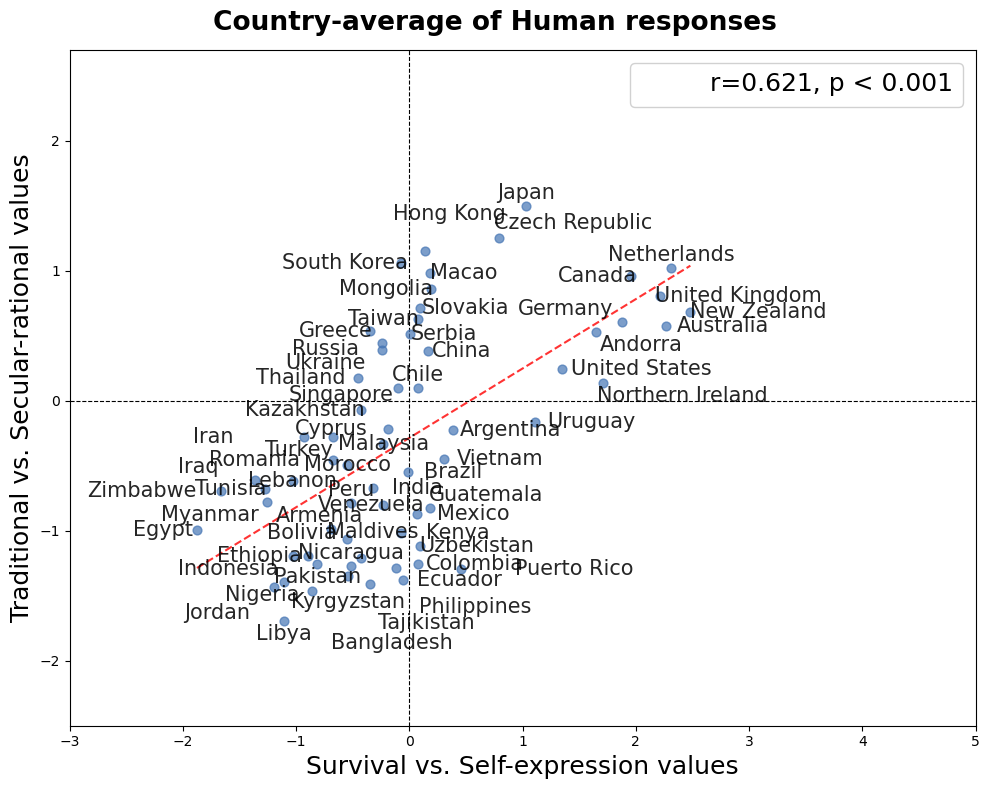

In [56]:
visualize_human()

In [ ]:
def visualize_llm(forced_llm):

    color = "#4575b4"
    group = df_llm[["TradAgg", "SurvsAgg"]].reset_index()

    model_row = group[group["Country"] == "model"]
    countries  = group[group["Country"] != "model"]

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    # scatter countries
    ax.scatter(countries["SurvsAgg"], countries["TradAgg"], color=color, alpha=0.7, s=40, zorder=3)

    # gold dot for model
    if not model_row.empty:
        ax.scatter(model_row["SurvsAgg"], model_row["TradAgg"],
                   color="gold", s=100, zorder=5, edgecolors="black", linewidths=0.8)

    # country labels (exclude model row from labels)
    texts = []
    for _, row in countries.iterrows():
        t = ax.text(row["SurvsAgg"], row["TradAgg"], row["Country"], fontsize=12, alpha=0.85)
        texts.append(t)

    adjust_text(texts, ax=ax,
                x=countries["SurvsAgg"].values, y=countries["TradAgg"].values,
                expand=(1.3, 1.5))

    # apply forced absolute positions
    for t, (_, row) in zip(texts, countries.iterrows()):
        ctry = row["Country"]
        if ctry in forced_llm:
            fdx, fdy = forced_llm[ctry]
            t.set_position((row["SurvsAgg"] + fdx, row["TradAgg"] + fdy))

    # arrows for far-displaced labels
    arrow_threshold = 2
    for t, (_, row) in zip(texts, countries.iterrows()):
        tx, ty = t.get_position()
        px, py = row["SurvsAgg"], row["TradAgg"]
        if ((tx - px)**2 + (ty - py)**2) ** 0.5 > arrow_threshold:
            ax.annotate("", xy=(px, py), xytext=(tx, ty),
                        arrowprops=dict(arrowstyle="->", color="gray", lw=0.6),
                        zorder=2)

    # linear trend (over countries only)
    slope, intercept = np.polyfit(countries["SurvsAgg"], countries["TradAgg"], 1)
    x_fit = np.linspace(countries["SurvsAgg"].min(), countries["SurvsAgg"].max(), 100)
    ax.plot(x_fit, slope * x_fit + intercept, color="red", linestyle="--", linewidth=1.5, alpha=0.8)
    r, p = pearsonr(countries["SurvsAgg"], countries["TradAgg"])
    print(p.round(3))

    # axes
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlim(-3, 5)
    ax.set_ylim(-2.5, 2.7)
    ax.set_xlabel("Emancipative values", fontsize=18)
    ax.set_ylabel("Secular values", fontsize=18)


    # legend
    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], marker="o", linestyle="", color=color, alpha=0.7,
               markersize=7, label="Country"),
        Line2D([0], [0], marker="o", linestyle="", color="gold",
               markersize=9, markeredgecolor="black", markeredgewidth=0.8, label=llm_name),
        Line2D([0], [0], color="red", linestyle="--", linewidth=1.5, alpha=0.8,
               label=f"Linear trend  r={r:.3f}, p < 0.001"),
    ]
    ax.legend(handles=legend_handles, loc="lower right", fontsize=14, framealpha=0.9)

    plt.suptitle(f"{llm_name} representations in the Inglehart-Welzel Cultural Space",
                 fontsize=19, fontweight="bold")
    plt.tight_layout()

    # plt.savefig('./supfig/IGW_spatio_'+llm_name+'.pdf', dpi=300, bbox_inches='tight')
    plt.show()


0.0


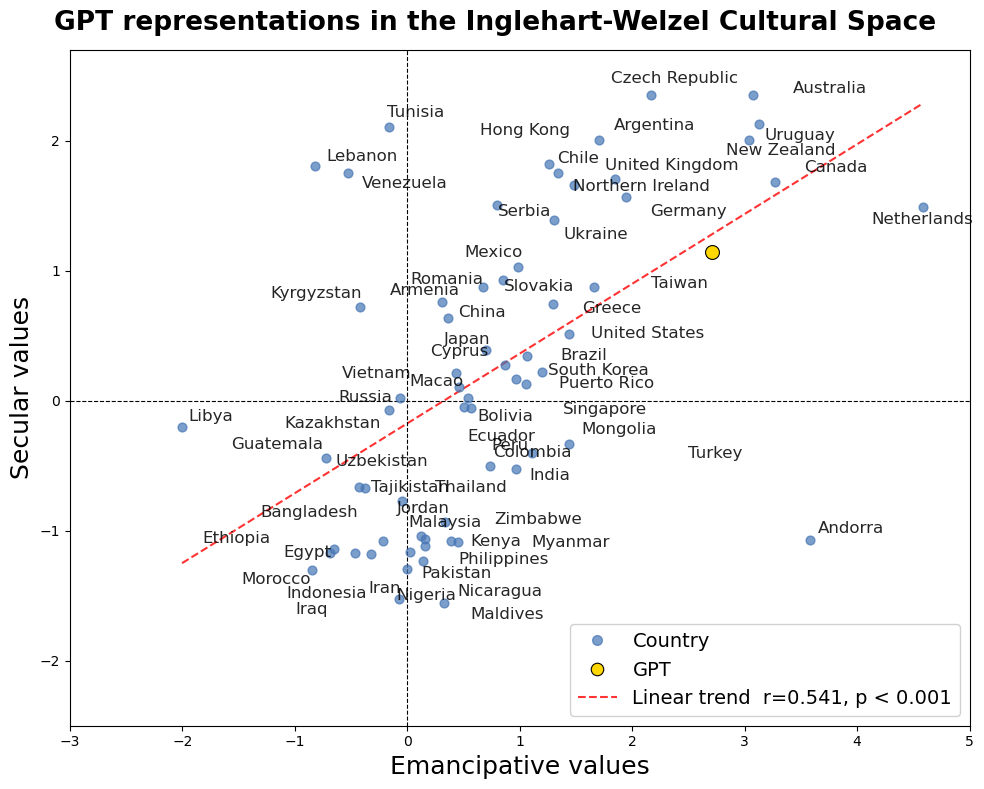

In [14]:
# adjust text locations to avoid overlap
forced_gpt = {
            "New Zealand": (0.2, -0.2), "United Kingdom": (0.5, 0.1), "United States": (0.7, 0.0),
            "Netherlands": (0.0, -0.1), "Northern Ireland": (0.6, -0.01),"Kazakhstan": (-0.5, -0.1),
            "South Korea": (0.5, 0.01), "Cyprus": (-0.4, 0.1),"Iraq": (0.0, -0.3),
            "Macao": (-0.2, 0.04), "Singapore": (0.7, -0.2),
            "Morocco": (-0.7, -0.2), "Egypt": (-0.2, 0.0),
            "Russia": (-0.3, 0.0), "Kenya": (0.4, 0.0),
            "Myanmar": (1.0, 0.0), "Nicaragua": (0.8, -0.3),
            "Pakistan": (0.3, -0.1), "Iran": (-0.2, -0.15),
            "Zimbabwe": (1, 0.15), "Romania": (-0.5, 0),"Uzbekistan": (0.2, 0.2),
            "Vietnam": (-0.7, 0), "Slovakia": (0.5, 0), "Brazil": (0.5, 0), "Colombia": (0, 0),"Malaysia": (0., 0),
            "Philippines": (0.7, -0.1), "Tajikistan": (0.4, 0.0),"Indonesia": (-0.4, -0.3),
        }

visualize_llm(forced_gpt)

In [ ]:
# ── shared helper ──────────────────────────────────────────────────────────
def draw_panel(ax, group, forced_positions, title, xlim, color="#4575b4"):
    model_row = group[group["Country"] == "model"]
    countries = group[group["Country"] != "model"]

    ax.scatter(countries["SurvsAgg"], countries["TradAgg"], color=color, alpha=0.7, s=40, zorder=3)
    if not model_row.empty:
        ax.scatter(model_row["SurvsAgg"], model_row["TradAgg"],
                   color="gold", s=100, zorder=5, edgecolors="black", linewidths=0.8)

    texts = []
    for _, row in group.iterrows():
        t = ax.text(row["SurvsAgg"], row["TradAgg"],
                    row["Country"], fontsize=13, alpha=0.85)
        texts.append(t)

    adjust_text(texts, ax=ax,
                x=group["SurvsAgg"].values, y=group["TradAgg"].values,
                expand=(1.3, 1.5))


    # apply forced absolute positions
    for t, (_, row) in zip(texts, group.iterrows()):
        ctry = row["Country"]
        if ctry in forced_positions:
            fdx, fdy = forced_positions[ctry]
            t.set_position((row["SurvsAgg"] + fdx, row["TradAgg"] + fdy))

    # conditional arrows
    arrow_threshold = 2
    for t, (_, row) in zip(texts, group.iterrows()):
        tx, ty = t.get_position()
        px, py = row["SurvsAgg"], row["TradAgg"]
        if ((tx - px)**2 + (ty - py)**2) ** 0.5 > arrow_threshold:
            ax.annotate("", xy=(px, py), xytext=(tx, ty),
                        arrowprops=dict(arrowstyle="->", color="gray", lw=0.6),
                        zorder=2)

    slope, intercept = np.polyfit(group["SurvsAgg"], group["TradAgg"], 1)
    x_fit = np.linspace(group["SurvsAgg"].min(), group["SurvsAgg"].max(), 100)
    ax.plot(x_fit, slope * x_fit + intercept, color="red", linestyle="--", linewidth=1.5, alpha=0.8)
    r, p = pearsonr(group["SurvsAgg"], group["TradAgg"])
    print(p.round(3))

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlim(*xlim)
    ax.set_xlim(-3, 5)
    ax.set_ylim(-2.5, 3)
    # ax.set_xlabel("Survival vs. Self-expression values", fontsize=20)
    ax.set_xlabel("Emancipative values", fontsize=20)
    
    ax.set_title(f"{title}\nr={r:.3f}, p < 0.001", fontsize=23)
    ax.tick_params(axis='both', labelsize=20)


def visualize_combine():
    
    fig, axes = plt.subplots(1, 2, figsize=(20, 9))

    # ── Panel A: Human ─────────────────────────────────────────────────────────

    forced_human = {
        "Japan": (0, 0.1), "Macao": (0.3, 0), "Mongolia": (-0.4, 0), "Slovakia": (0.4, 0),
        "Taiwan": (-0.3, 0), "Greece": (-0.3, 0),"Serbia": (0.3, 0), "China": (0.3, 0),
        "Ukraine": (-0.5, -0.1), "Russia": (-0.5, -0.05),"Singapore": (-0.5, -0.05), "Chile": (0, +0.1),
        "Argentina": (0, 0), "Armenia": (-0.1, 0.1),
        "Andorra": (0.4, -0.1), "United States": (0.7, 0), "Northern Ireland": (0.7, -0.1),
        "Uruguay": (0.5, 0), "Argentina": (0.5, 0), "Vietnam": (0.5, 0), "Brazil": (0.4, 0), "India": (0.4, 0),
        "Cyprus": (-0.5, 0),"Iran": (-0.8, 0), "Tunisia": (-0.3, 0),"Egypt": (-0.3, 0),
        "Myanmar": (-0.5, -0.1),"Kenya": (0.5, 0),"Uzbekistan": (0.5, 0),"Libya": (0, -0.1),
        "Jordan": (-0.5, -0.2), "Puerto Rico": (1.0, 0), "Nicaragua": (-0, +0.1), "Guatemala": (0.5, +0.1), 
        "Mexico": (0.5, 0), "Turkey": (-0.3, -0.1), "Iraq": (-0.5, 0.1), "Romania": (-0.7, 0),
        "Peru": (0.0, 0.1), "Venezuela": (-0.1, -0.0),"Bolivia": (-0.4, 0.05), "Bangladesh": (0.7, -0.4), 
        "Nigeria": (-0.2, -0.1), "Colombia": (0.5, 0),  "Ecuador": (0.5, 0),  "Tajikistan": (0.5, -0.3),
        "Kyrgyzstan": (0, -0.2), "Maldives": (0.1, 0.2), "Pakistan": (0, -0.1), "Indonesia": (-0.7, -0.1),
        "Ethiopia": (-0.3, 0), "Australia": (0.5, 0), "Canada": (-0.3, 0), "Philippines": (0.7, -0.3),  
        "Zimbabwe": (-0.7, 0),"Germany": (-0.5, 0.1), "Kazakhstan": (-0.5, 0),"Lebanon": (0, 0),
        "Malaysia": (0, 0),"Morocco": (0, 0),  "Netherlands": (0.0, 0.1),"New Zealand": (0.6, 0),  
        "South Korea": (-0.5, 0),  "Thailand": (-0.5, 0), "United Kingdom": (0.7, 0),
    }
    group_human = df_avg[["TradAgg", "SurvsAgg"]].reset_index()
    draw_panel(axes[0], group_human, forced_human,
               "Country-average of Human responses", (-3, 5))
    # axes[0].set_ylabel("Traditional vs. Secular-rational values", fontsize=20)
    axes[0].set_ylabel("Secular values", fontsize=20)

    # ── Panel B: LLM ───────────────────────────────────────────────────────────

    forced_gpt = {
        "New Zealand": (0.2, -0.2), "United Kingdom": (0.5, 0.1), "United States": (0.7, 0.0),
        "Netherlands": (0.0, -0.1), "Northern Ireland": (0.6, -0.01),"Kazakhstan": (-0.5, -0.1),
        "South Korea": (0.5, 0.01), "Cyprus": (-0.4, 0.1),"Iraq": (0.0, -0.3),
        "Macao": (-0.2, 0.04), "Singapore": (0.7, -0.2),
        "Morocco": (-0.7, -0.2), "Egypt": (-0.2, 0.0),
        "Russia": (-0.3, 0.0), "Kenya": (0.4, 0.0),
        "Myanmar": (1.0, 0.0), "Nicaragua": (0.8, -0.3),
        "Pakistan": (0.3, -0.1), "Iran": (-0.2, -0.15),
        "Zimbabwe": (1, 0.15), "Romania": (-0.5, 0),"Uzbekistan": (0.2, 0.2),
        "Vietnam": (-0.7, 0), "Slovakia": (0.5, 0), "Brazil": (0.5, 0), "Colombia": (0, 0),"Malaysia": (0., 0),
        "Philippines": (0.7, -0.1), "Tajikistan": (0.4, 0.0),"Indonesia": (-0.4, -0.3),
    }
    group_llm = df_llm[["TradAgg", "SurvsAgg"]].reset_index()
    draw_panel(axes[1], group_llm, forced_gpt,
               f"Culturally prompted {llm_name} responses", (-3, 5))
    

    # plt.suptitle("Human and LLM representations in the Inglehart-Welzel Cultural Space",
    #              fontsize=23, fontweight="bold")
    plt.tight_layout()
    
    # plt.savefig('./mainfig/3A_spatio.pdf', dpi=300, bbox_inches='tight')
    plt.show()

0.0
0.0


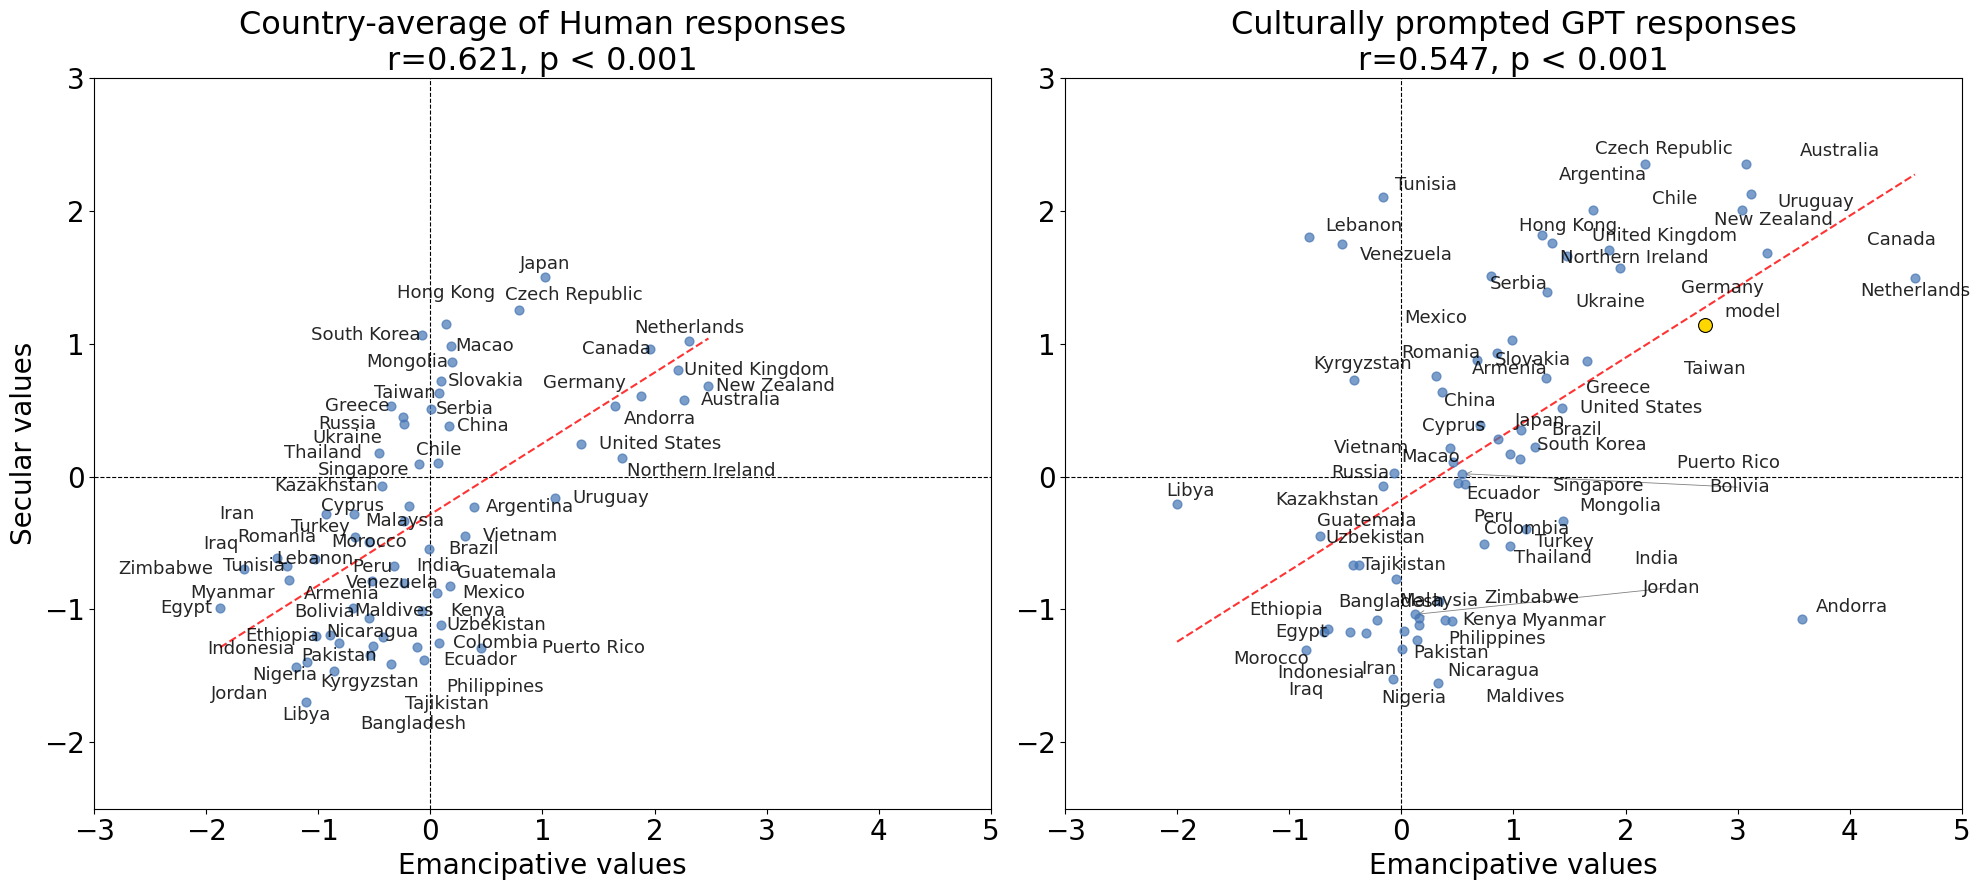

In [16]:
visualize_combine()

#### Shift from WVS to LLM

In [17]:
# Shift from WVS representation to LLM representation, for each country
def get_shift(df_llm, df_avg):
    shift_df = df_avg[["TradAgg", "SurvsAgg"]].join(
        df_llm[["TradAgg", "SurvsAgg"]],
        lsuffix="_wvs", rsuffix="_llm",
        how="inner",
    )

    shift_df["dSurvsAgg"] = shift_df["SurvsAgg_llm"] - shift_df["SurvsAgg_wvs"]
    shift_df["dTradAgg"] = shift_df["TradAgg_llm"] - shift_df["TradAgg_wvs"]

    return shift_df

shift_df = get_shift(df_llm, df_avg)

In [ ]:
def visualize_shift(shift_df):
    fig, ax = plt.subplots(figsize=(12, 8)) # for Claude and DeepSeek
    # fig, ax = plt.subplots(figsize=(20, 12)) # for GPT

    margin = 0.5
    # print(shift_df["dSurvsAgg"].min(), shift_df["dSurvsAgg"].max())
    # print(shift_df["dTradAgg"].min(), shift_df["dTradAgg"].max())
        
    ax.set_xlim(shift_df["dSurvsAgg"].min() - margin, shift_df["dSurvsAgg"].max() + margin)
    ax.set_ylim(shift_df["dTradAgg"].min() - margin, shift_df["dTradAgg"].max() + margin)

    # arrows from origin to each country's shift vector
    for country, row in shift_df.iterrows():
        ax.annotate(
            "",
            xy=(row["dSurvsAgg"], row["dTradAgg"]),
            xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color="gray", alpha=0.6, lw=1),
        )

    # place text labels at arrow tips, then adjust to avoid overlaps
    xs = shift_df["dSurvsAgg"].values
    ys = shift_df["dTradAgg"].values
    texts = []
    for country, row in shift_df.iterrows():
        t = ax.text(row["dSurvsAgg"], row["dTradAgg"], country,
                    fontsize=17, color="black", alpha=0.85)
        texts.append(t)

    adjust_text(texts, ax=ax, x=xs, y=ys,
                expand=(1.4, 1.6),
                arrowprops=dict(arrowstyle="-", color="gray", alpha=0.5, lw=0.7))

    ax.axhline(0, color="red", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="red", linewidth=0.8, linestyle="--")
    if llm_name == "GPT":
        ax.set_xlabel("Emancipative values \n(human --> culturally prompted " + llm_name + ")", fontsize=25)
        ax.set_ylabel("Secular values \n(human --> culturally prompted " + llm_name + ")", fontsize=25)
    else:
        ax.set_xlabel("Emancipative values \n(human --> culturally prompted " + llm_name + ")", fontsize=20)
        ax.set_ylabel("Secular values \n(human --> culturally prompted " + llm_name + ")", fontsize=20)

    ax.tick_params(axis="both", labelsize=20)
    # ax.set_xlim(-3, 5)
    # ax.set_ylim(-2.5, 3)
    ax.set_title("Shift from Human to " + llm_name + " representation", fontsize=25, fontweight="bold")
    plt.tight_layout()
    # plt.savefig("./supfig/IGW_shift_" + llm_name + ".pdf", dpi=300, bbox_inches="tight")
    plt.show()


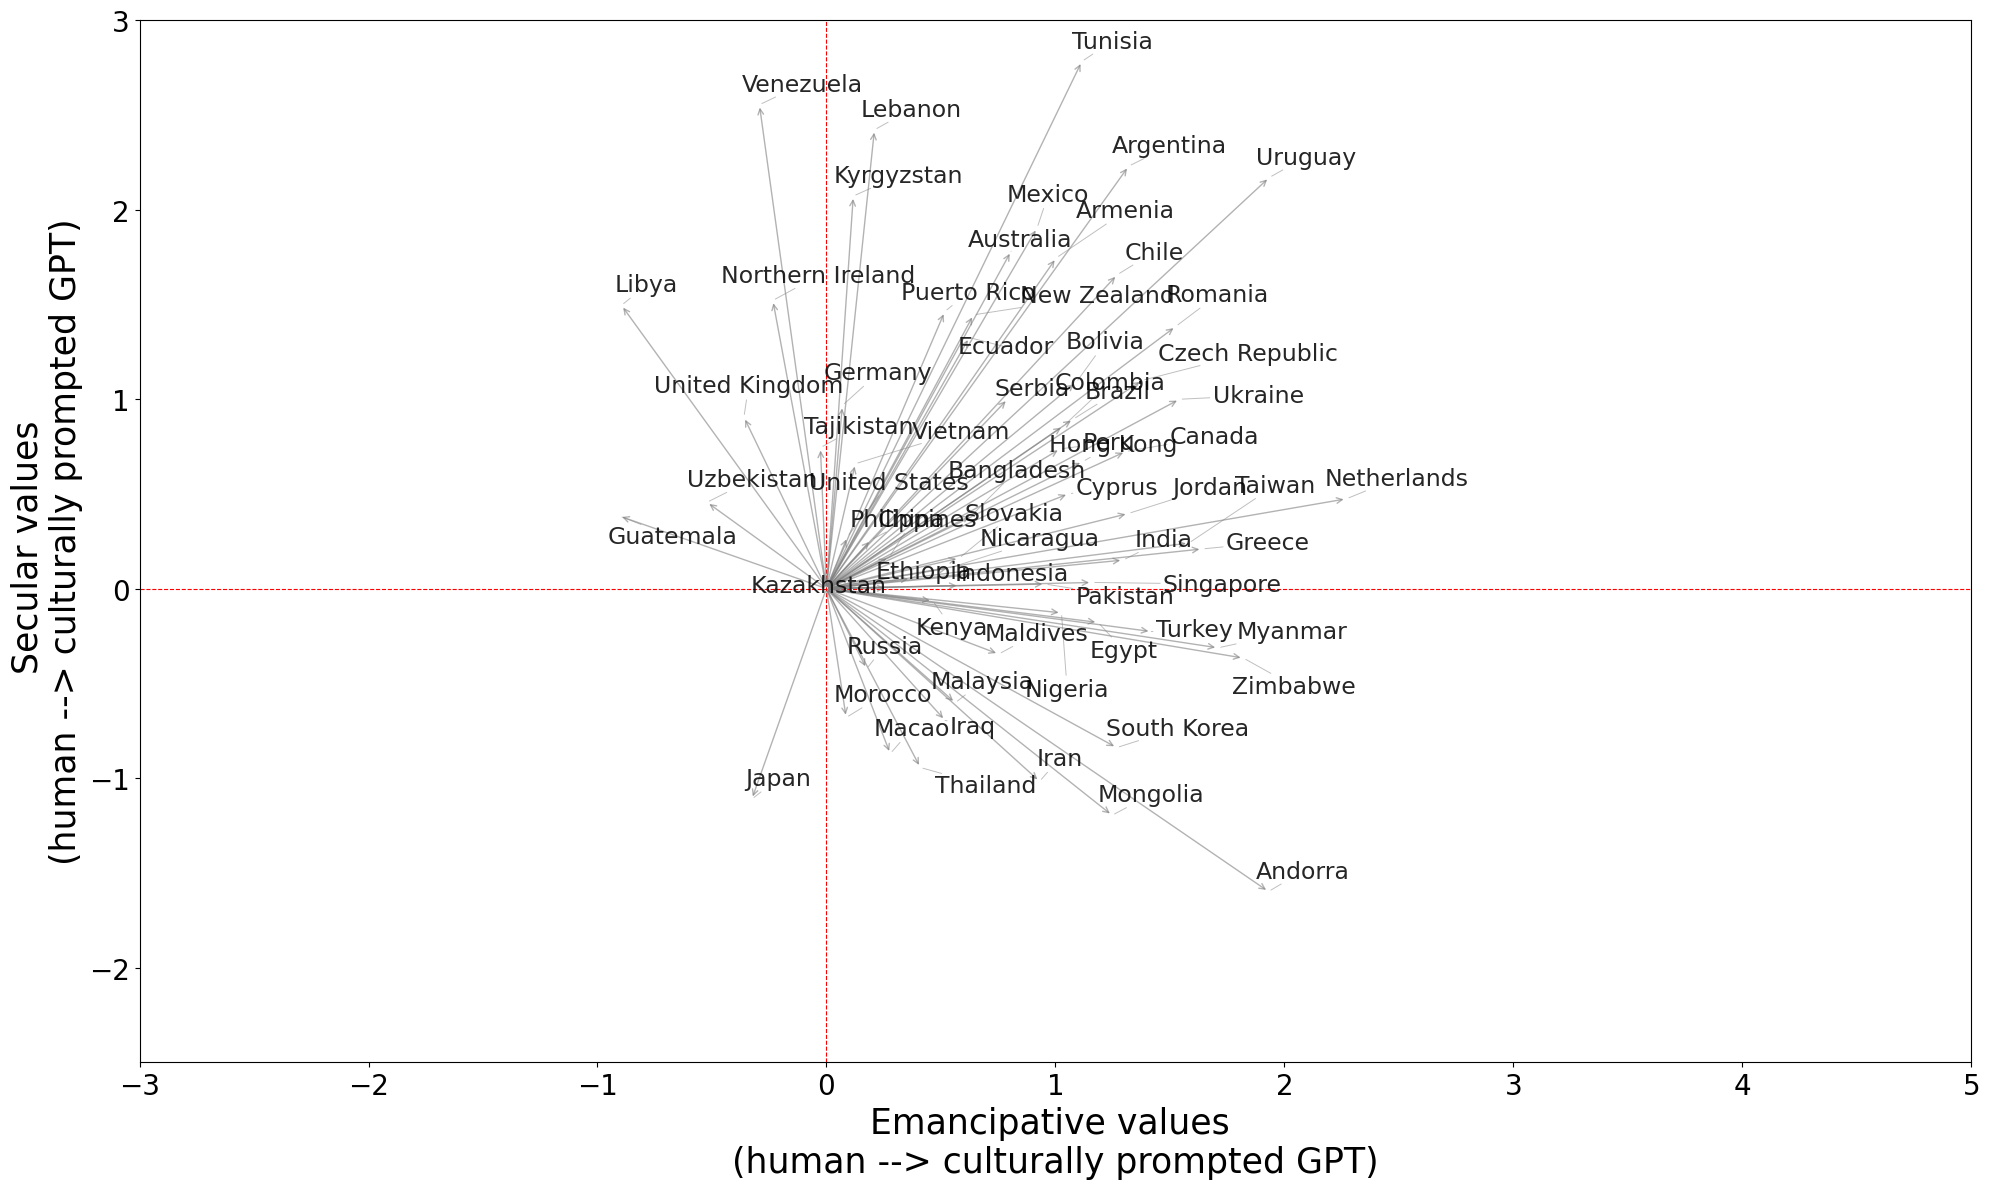

In [39]:
visualize_shift(shift_df)

In [25]:
shift_df.head()

,TradAgg_wvs,SurvsAgg_wvs,TradAgg_llm,SurvsAgg_llm,dSurvsAgg,dTradAgg
Country,,,,,,
Andorra,0.530590,1.646620,-1.068120,3.577483,1.930862,-1.598710
Argentina,-0.225108,0.388645,2.003611,1.708732,1.320087,2.228719
Armenia,-0.986389,-0.690974,0.758416,0.312892,1.003866,1.744805
Australia,0.574894,2.266723,2.354633,3.073242,0.806520,1.779739
Bangladesh,-1.465614,-0.856447,-1.076344,-0.219110,0.637337,0.389269


In [26]:
n_1q = shift_df[(shift_df['dSurvsAgg']>0) & (shift_df['dTradAgg']>0)].shape[0]
n_2q = shift_df[(shift_df['dSurvsAgg']<0) & (shift_df['dTradAgg']>0)].shape[0]
n_3q = shift_df[(shift_df['dSurvsAgg']<0) & (shift_df['dTradAgg']<0)].shape[0]
n_4q = shift_df[(shift_df['dSurvsAgg']>0) & (shift_df['dTradAgg']<0)].shape[0]

n_1q, n_2q, n_3q, n_4q

(41, 7, 1, 17)

In [27]:
# 15 countries that move in negative directions
shift_df[(shift_df['dSurvsAgg'] < 0) | (shift_df['dTradAgg'] < 0)].index

Index(['Andorra', 'Egypt', 'Guatemala', 'Iran', 'Iraq', 'Japan', 'Kenya',
       'Libya', 'Macao', 'Malaysia', 'Maldives', 'Mongolia', 'Morocco',
       'Myanmar', 'Nigeria', 'Northern Ireland', 'Russia', 'South Korea',
       'Tajikistan', 'Thailand', 'Turkey', 'United Kingdom', 'Uzbekistan',
       'Venezuela', 'Zimbabwe'],
      dtype='object', name='Country')

#### Group by WVS cultural zones
- English-speaking
- Protestant Europe
- Catholic Europe
- Orthodox
- Confucian
- West and South Asia
- Latin America
- African-Islamic

In [34]:
# WVS cultural zones (Inglehart-Welzel World Cultural Map, approximate wave-7 grouping;
# a few boundary countries, e.g. Turkey/Iraq/Jordan/Lebanon, vary slightly by map version)
country_to_zone = {
    "Australia": "English-Speaking", "New Zealand": "English-Speaking", "Canada": "English-Speaking",
    "United States": "English-Speaking", "Northern Ireland": "English-Speaking", "United Kingdom": "English-Speaking",
    "Germany": "Protestant Europe", "Netherlands": "Protestant Europe",
    "Andorra": "Catholic Europe", "Czech Republic": "Catholic Europe", "Slovakia": "Catholic Europe",
    "Romania": "Orthodox", "Russia": "Orthodox", "Ukraine": "Orthodox", "Greece": "Orthodox",
    "Serbia": "Orthodox", "Armenia": "Orthodox", "Cyprus": "Orthodox",
    "China": "Confucian", "Hong Kong": "Confucian", "Japan": "Confucian", "Macao": "Confucian",
    "Mongolia": "Confucian", "South Korea": "Confucian", "Taiwan": "Confucian", "Vietnam": "Confucian",
    "Singapore": "Confucian",
    "Kazakhstan": "West and South Asia", "Kyrgyzstan": "West and South Asia", "Tajikistan": "West and South Asia",
    "Uzbekistan": "West and South Asia", "Indonesia": "West and South Asia", "Malaysia": "West and South Asia",
    "Myanmar": "West and South Asia", "Philippines": "West and South Asia", "Thailand": "West and South Asia",
    "Bangladesh": "West and South Asia", "India": "West and South Asia", "Iran": "West and South Asia",
    "Maldives": "West and South Asia", "Pakistan": "West and South Asia", "Turkey": "West and South Asia",
    "Argentina": "Latin America", "Bolivia": "Latin America", "Brazil": "Latin America", "Chile": "Latin America",
    "Colombia": "Latin America", "Ecuador": "Latin America", "Guatemala": "Latin America", "Mexico": "Latin America",
    "Nicaragua": "Latin America", "Peru": "Latin America", "Puerto Rico": "Latin America", "Uruguay": "Latin America",
    "Venezuela": "Latin America",
    "Egypt": "African-Islamic", "Libya": "African-Islamic", "Morocco": "African-Islamic", "Tunisia": "African-Islamic",
    "Ethiopia": "African-Islamic", "Kenya": "African-Islamic", "Nigeria": "African-Islamic", "Zimbabwe": "African-Islamic",
    "Iraq": "African-Islamic", "Jordan": "African-Islamic", "Lebanon": "African-Islamic",
}

shift_df["cultural_zone"] = shift_df.index.map(country_to_zone)

zones = sorted(shift_df["cultural_zone"].unique())
zone_palette = plt.cm.get_cmap("tab20", len(zones))
zone_colors = {zone: zone_palette(i) for i, zone in enumerate(zones)}

/var/folders/c0/k3x4vq2s6gq08cgr4vmzcdz40000gp/T/ipykernel_57882/233645870.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  zone_palette = plt.cm.get_cmap("tab20", len(zones))


In [ ]:
def visualize_cultural_facet():

    import math

    # Manual label offsets for the African-Islamic panel (dx, dy from data point)
    forced_af_islamic = {
        "Libya":     ( 0.0,   0.0),
        "Lebanon":   ( 0.0,   0.3),
        "Zimbabwe":  ( 0.4,   0.2),
        "Nigeria":   ( 0.4,   0.0),
        "Iraq":      (-0.5,   0.15),
        "Jordan":    (-0.5,  -0.1),
        "Kenya":     (-0.4,  -0.25),
        "Egypt":     ( 0.3,  -0.25),
        "Ethiopia":  ( 0.5,  -0.05),
        "Tunisia":   ( 0.5,  -0.2),
        "Morocco":   ( 0.0,   0.0),
    }

    zones_list = sorted(shift_df["cultural_zone"].unique())
    n_zones = len(zones_list)
    ncols = 4
    nrows = math.ceil(n_zones / ncols)

    margin = 0.5
    xlim = (shift_df["dSurvsAgg"].min() - margin, shift_df["dSurvsAgg"].max() + margin)
    ylim = (shift_df["dTradAgg"].min() - margin, shift_df["dTradAgg"].max() + margin)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows), sharex=True, sharey=True)
    axes = axes.flatten()

    for ax_idx, (ax, zone) in enumerate(zip(axes, zones_list)):
        group = shift_df[shift_df["cultural_zone"] == zone]
        color = "deeppink" if zone == "Protestant Europe" else zone_colors[zone]

        # draw shift arrows from origin
        for country, row in group.iterrows():
            ax.annotate(
                "",
                xy=(row["dSurvsAgg"], row["dTradAgg"]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=color, alpha=0.8, lw=1.5),
            )

        xs = group["dSurvsAgg"].values
        ys = group["dTradAgg"].values
        texts = []
        for country, row in group.iterrows():
            t = ax.text(row["dSurvsAgg"], row["dTradAgg"], country, fontsize=13, alpha=0.9)
            texts.append(t)

        if zone == "African-Islamic":
            # apply manual offsets instead of adjust_text for this panel
            for t, (country, row) in zip(texts, group.iterrows()):
                if country in forced_af_islamic:
                    fdx, fdy = forced_af_islamic[country]
                    t.set_position((row["dSurvsAgg"] + fdx, row["dTradAgg"] + fdy))
            # draw thin connector lines where label moved significantly
            arrow_threshold = 0.05
            for t, (country, row) in zip(texts, group.iterrows()):
                tx, ty = t.get_position()
                px, py = row["dSurvsAgg"], row["dTradAgg"]
                if ((tx - px)**2 + (ty - py)**2) ** 0.5 > arrow_threshold:
                    ax.annotate("", xy=(px, py), xytext=(tx, ty),
                                arrowprops=dict(arrowstyle="-", color="gray", alpha=0.5, lw=0.7))
        else:
            adjust_text(texts, ax=ax, x=xs, y=ys,
                        expand=(1.5, 1.7),
                        arrowprops=dict(arrowstyle="-", color="gray", alpha=0.5, lw=0.7))

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
        ax.axvline(0, color="black", linewidth=0.6, linestyle="--")
        ax.set_xlabel(zone, fontsize=15, fontweight="bold")
        ax.tick_params(axis="both", labelsize=13)

    for ax in axes[n_zones:]:
        ax.axis("off")

    fig.supxlabel("Emancipative values (human --> culturally prompted " + llm_name + ")", fontsize=18)
    fig.supylabel("Secular values (human --> culturally prompted " + llm_name + ")", fontsize=18)
    fig.suptitle("Shift from Human to " + llm_name + " country representation, faceted by WVS cultural zone",
                 fontsize=23, fontweight="bold")
    plt.tight_layout()
    # plt.savefig("./supfig/IGW_czone_" + llm_name + ".pdf", dpi=300, bbox_inches="tight")
    plt.show()


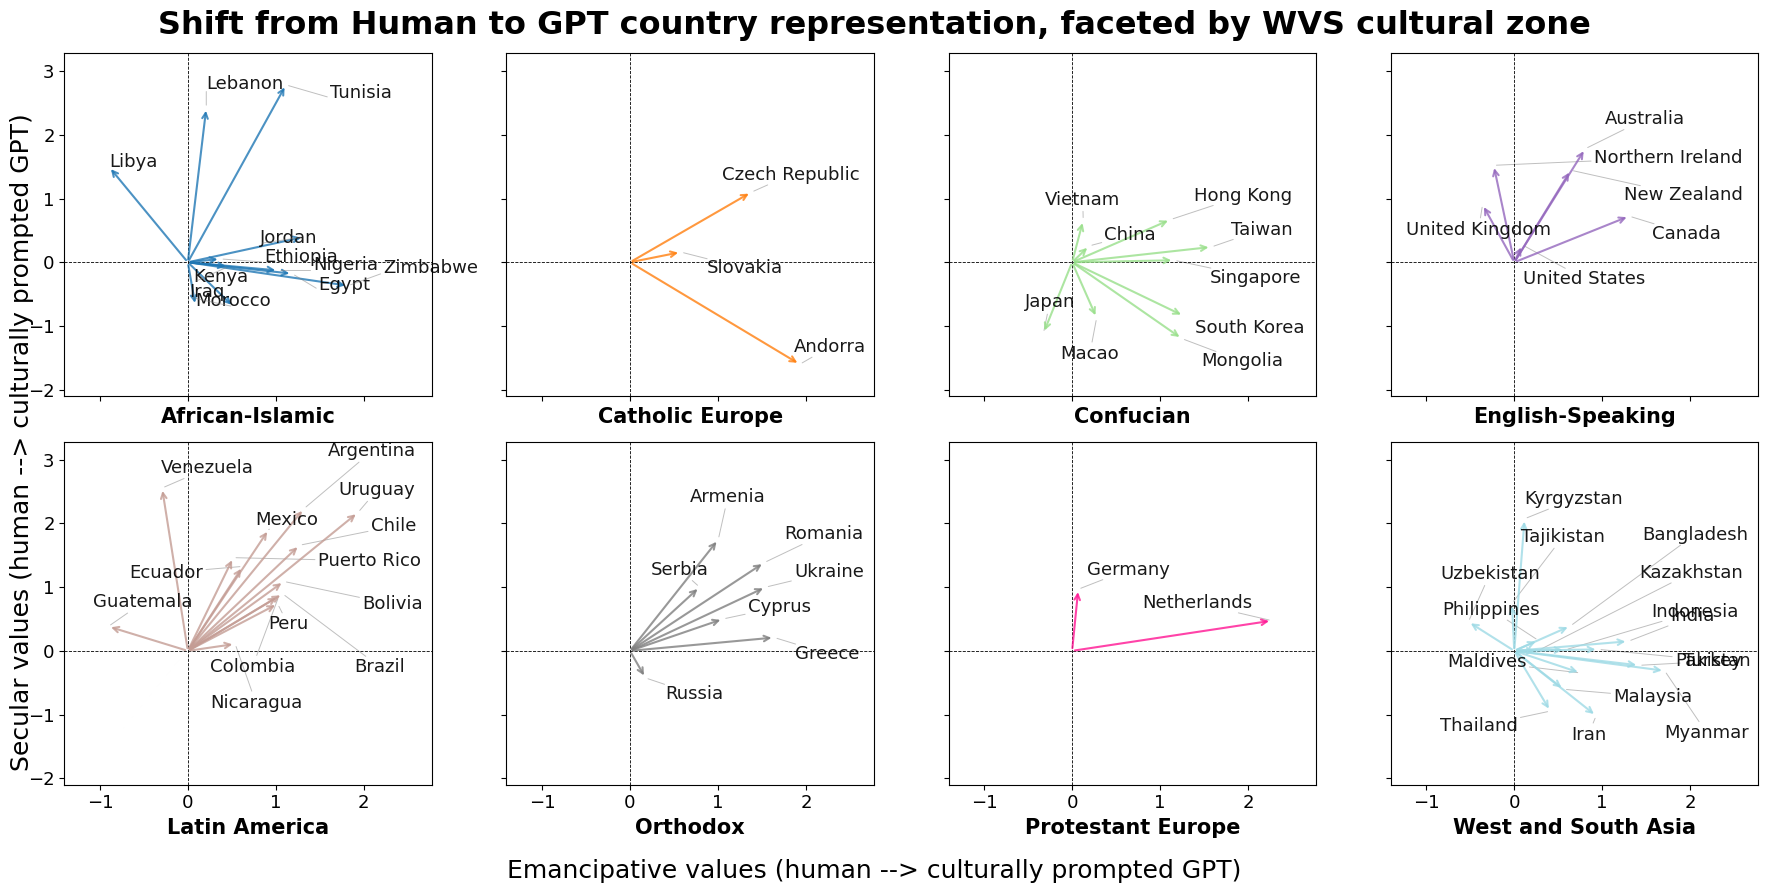

In [36]:
visualize_cultural_facet()

#### t-tests
- compare between country distributions under human and LLM representations

In [36]:
def one_sample_ttest_llm_default():

    for IG_dim in ["TradAgg", "SurvsAgg"]:
        v_llm  = df_llm.loc["model", IG_dim]
        v_ctry = df_llm.loc[all_countries][IG_dim].values
        ttest  = stats.ttest_1samp(v_ctry, popmean=v_llm)

        print(f"{llm_name} — {IG_dim} ({v_llm:.3f})")
        print(f"  Mean:{v_ctry.mean().round(3)}, "
              f"SD:{v_ctry.std(ddof=1).round(3)}, "
              f"t:{ttest.statistic.round(3)}, "
              f"p:{ttest.pvalue.round(3)}")
        print()


def paired_ttest():

    for IG_dim in ["TradAgg", "SurvsAgg"]:
        IG_before = df_avg.loc[all_countries, IG_dim]
        IG_after  = df_llm.loc[all_countries, IG_dim]

        result = stats.ttest_rel(IG_after, IG_before)
        diff   = IG_after - IG_before

        print(f"{llm_name} — {IG_dim}")
        print(f"  Mean diff (after - before): {diff.mean():.3f}, SD: {diff.std(ddof=1):.3f}")
        print(f"  t = {result.statistic:.3f}, p = {result.pvalue:.3f}")
        print()

def paired_ttest_bydist():

    for IG_dim in ["TradAgg", "SurvsAgg"]:
        dist2prompted = df_llm.loc[all_countries, IG_dim] - df_avg.loc[all_countries, IG_dim]
        dist2default  = df_llm.loc['model', IG_dim] - df_avg.loc[all_countries, IG_dim]

        result = stats.ttest_rel(dist2prompted, dist2default)
        diff   = dist2prompted - dist2default

        print(f"{llm_name} — {IG_dim}")
        print(f"  Mean diff (after - before): {diff.mean():.3f}, SD: {diff.std(ddof=1):.3f}")
        print(f"  t = {result.statistic:.3f}, p = {result.pvalue:.3f}")
        print()


In [37]:
one_sample_ttest_llm_default()

GPT — TradAgg (1.143)
  Mean:0.215, SD:1.173, t:-6.423, p:0.0

GPT — SurvsAgg (2.706)
  Mean:0.724, SD:1.18, t:-13.642, p:0.0



In [38]:
paired_ttest()

GPT — TradAgg
  Mean diff (after - before): 0.514, SD: 0.991
  t = 4.218, p = 0.000

GPT — SurvsAgg
  Mean diff (after - before): 0.752, SD: 0.686
  t = 8.899, p = 0.000



In [39]:
paired_ttest_bydist()

GPT — TradAgg
  Mean diff (after - before): -0.927, SD: 1.173
  t = -6.423, p = 0.000

GPT — SurvsAgg
  Mean diff (after - before): -1.982, SD: 1.180
  t = -13.642, p = 0.000



### Replicate results for Claude

In [42]:
# LLM country representation
llm_name = 'Claude' 
df_llm = df_claude 

df_avg["TradAgg"] = trad_model.predict(df_avg[items])
df_avg["SurvsAgg"] = survs_model.predict(df_avg[items])

df_llm["TradAgg"] = trad_model.predict(df_llm[items])
df_llm["SurvsAgg"] = survs_model.predict(df_llm[items])

0.0


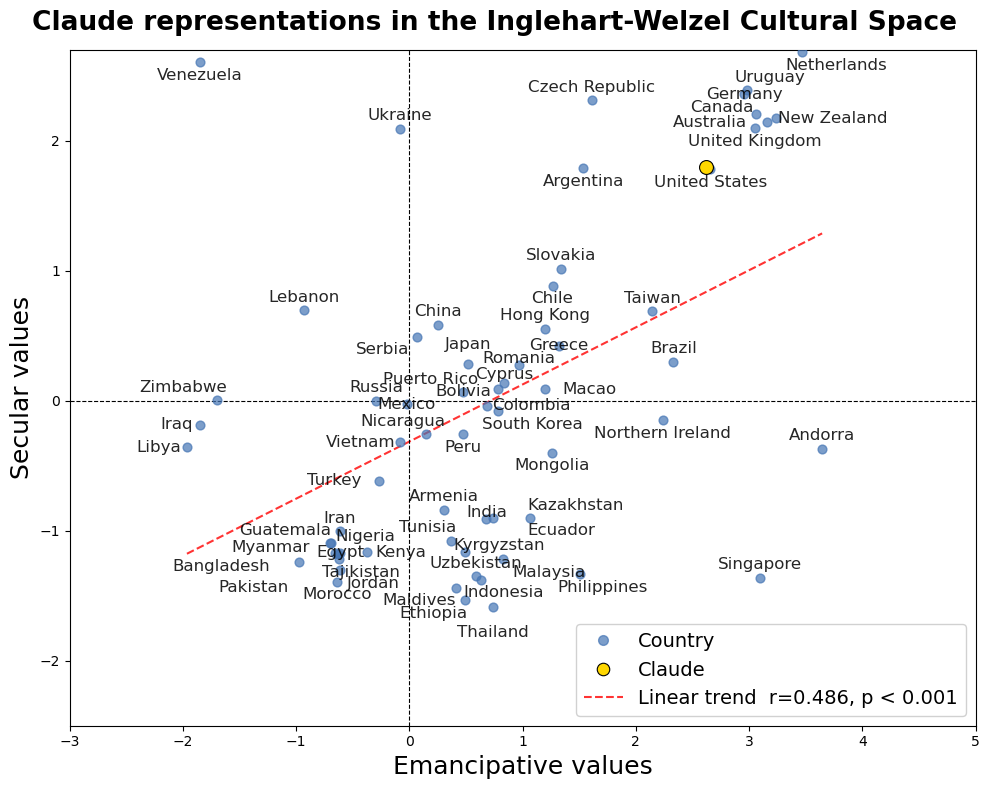

In [43]:
# adjust text locations to avoid overlap

forced_claude = {
    "Andorra": (0.0, 0.1),
    "Argentina": (0.0, -0.1),
    "Armenia": (0.0, 0.1),
    "Australia": (-0.5, 0.0),
    "Bangladesh": (-1, -0.1),
    "Bolivia": (-0.0, 0.0),
    "Brazil": (0.0, 0.1),
    "Canada": (-0.3, 0.05),
    "Chile": (0.0, -0.1),
    "China": (0.0, 0.1),
    "Colombia": (0.4, 0.0),
    "Cyprus": (0.0, 0.07),
    "Czech Republic": (0.0, 0.1),
    "Ecuador": (0.6, -0.1),
    "Egypt": (0.0, 0.0),
    "Ethiopia": (-0.2, -0.2),
    "Germany": (0.0, 0.0),
    "Greece": (0.0, 0.0),
    "Guatemala": (-0.4, 0.1),
    "Hong Kong": (0.0, 0.1),
    "India": (0.0, 0.05),
    "Indonesia": (0.2, -0.1),
    "Iran": (0.0, 0.1),
    "Iraq": (-0.2, 0.0),
    "Japan": (0.0, 0.15),
    "Jordan": (0.3, -0.1),
    "Kazakhstan": (0.4, 0.1),
    "Kenya": (0.3, 0.0),
    "Kyrgyzstan": (0.3, 0.05),
    "Lebanon": (0.0, 0.1),
    "Libya": (-0.25, 0.0),
    "Macao": (0.4, 0.0),
    "Malaysia": (0.4, -0.1),
    "Maldives": (-0.4, 0.0),
    "Mexico": (0.0, 0.0),
    "Mongolia": (0.0, -0.1),
    "Morocco": (0.0, -0.1),
    "Myanmar": (-0.6, 0.05),
    "Netherlands": (0.3, -0.1),
    "New Zealand": (0.5, 0.0),
    "Nicaragua": (-0.2, 0.1),
    "Nigeria": (0.3, 0.05),
    "Northern Ireland": (0.0, -0.1),
    "Pakistan": (-0.4, -0.2),
    "Peru": (0.0, -0.1),
    "Philippines": (0.2, -0.1),
    "Puerto Rico": (-0.6, 0.07),
    "Romania": (0.0, 0.05),
    "Russia": (0.0, 0.1),
    "Serbia": (-0.3, -0.1),
    "Singapore": (0.0, 0.1),
    "Slovakia": (0.0, 0.1),
    "South Korea": (0.3, -0.1),
    "Taiwan": (0.0, 0.1),
    "Tajikistan": (0.2, -0.1),
    "Thailand": (0.0, -0.2),
    "Tunisia": (-0.2, 0.1),
    "Turkey": (-0.4, 0.0),
    "Ukraine": (0.0, 0.1),
    "United Kingdom": (0.0, -0.1),
    "United States": (0.0, -0.1),
    "Uruguay": (0.2, 0.1),
    "Uzbekistan": (0.0, 0.1),
    "Venezuela": (0.0, -0.1),
    "Vietnam": (-0.35, 0.0),
    "Zimbabwe": (-0.3, 0.1),
}

visualize_llm(forced_claude)


In [44]:
shift_df = get_shift(df_llm, df_avg)

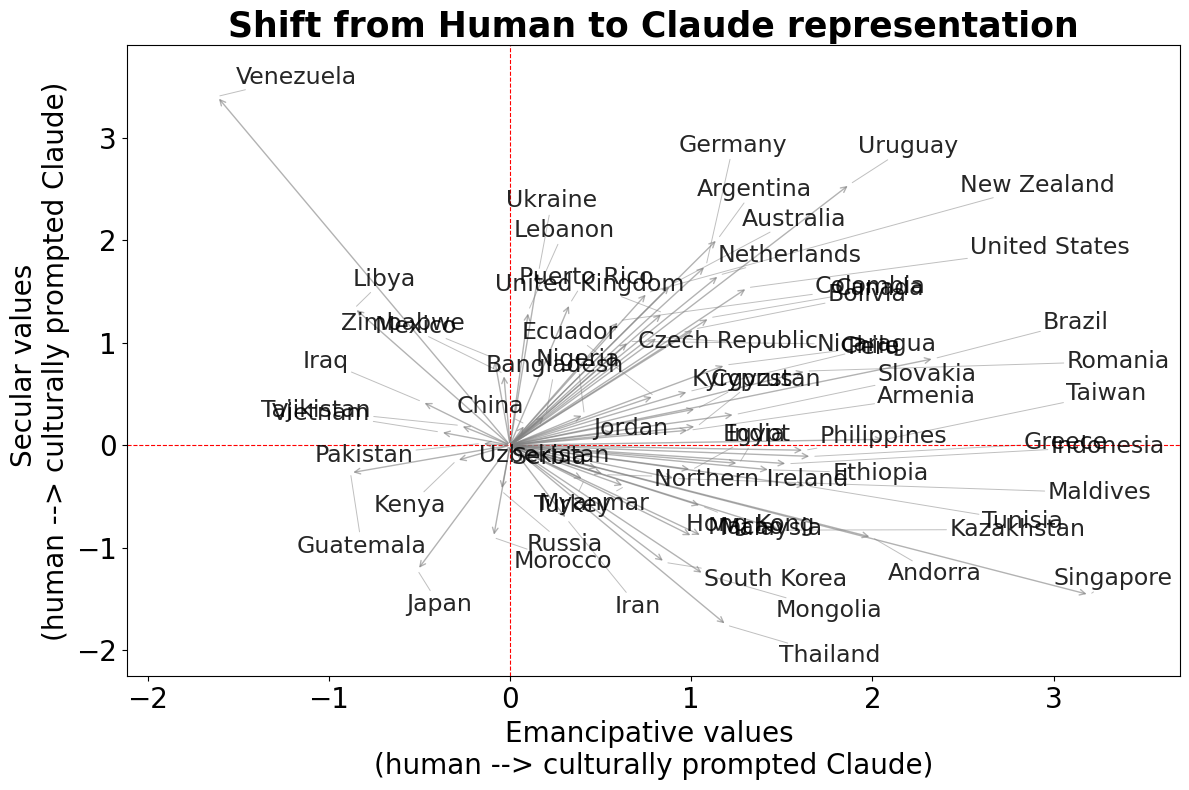

In [50]:
visualize_shift(shift_df)

/var/folders/c0/k3x4vq2s6gq08cgr4vmzcdz40000gp/T/ipykernel_57882/1564039379.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  zone_palette = plt.cm.get_cmap("tab20", len(zones))


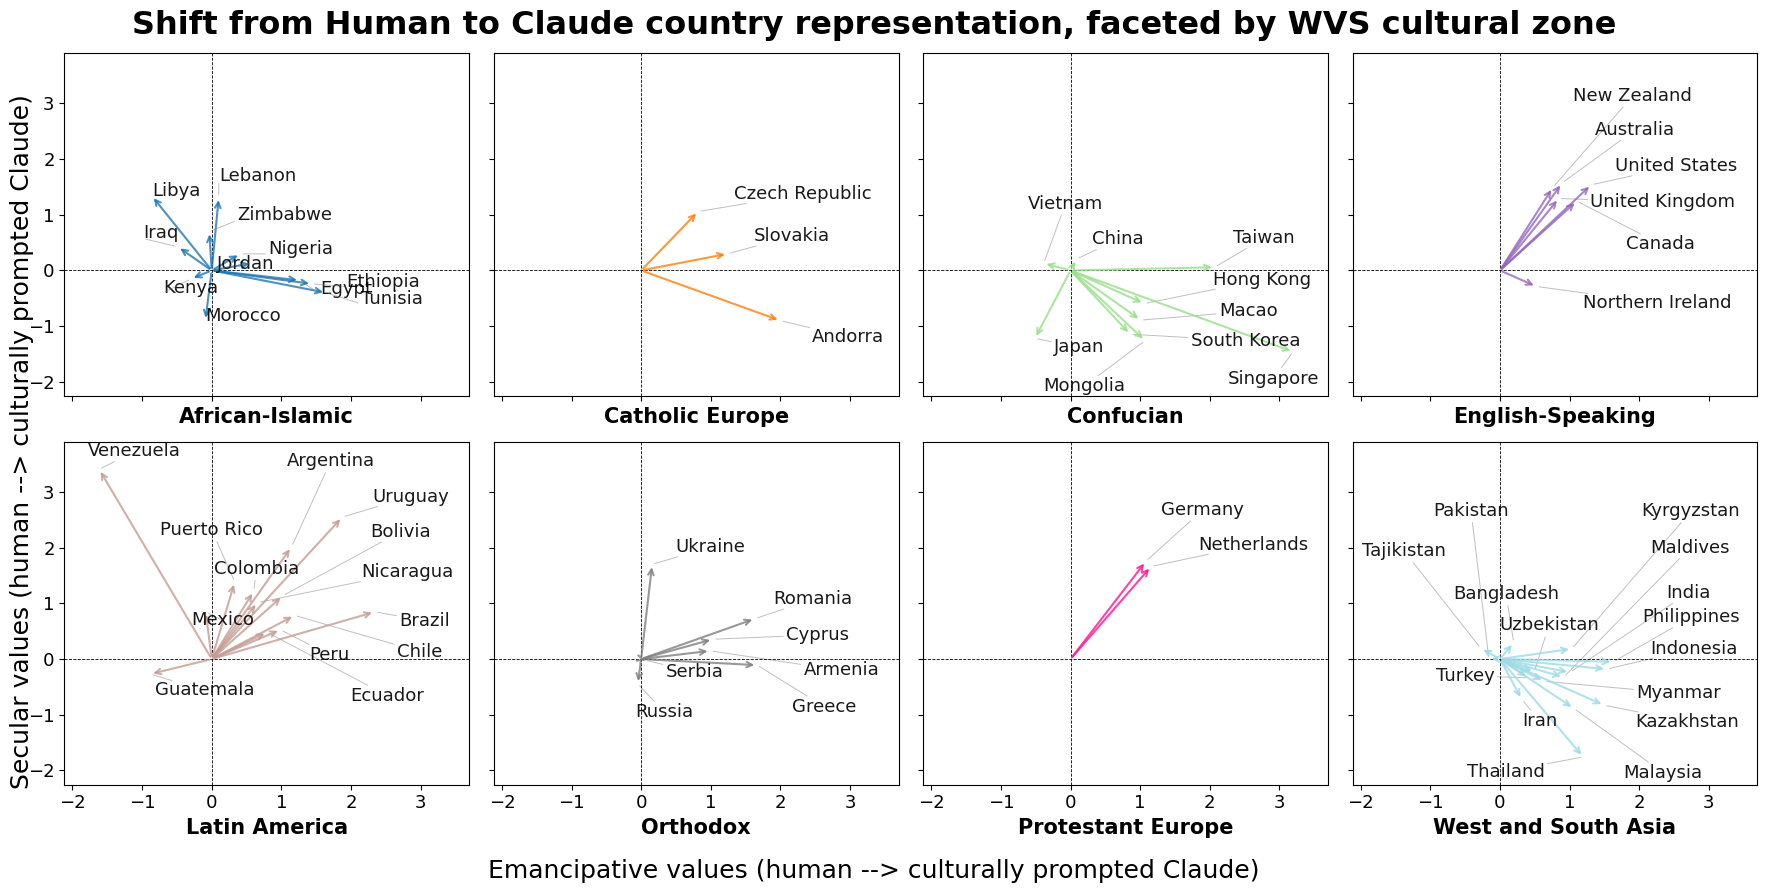

In [48]:
shift_df["cultural_zone"] = shift_df.index.map(country_to_zone)

zones = sorted(shift_df["cultural_zone"].unique())
zone_palette = plt.cm.get_cmap("tab20", len(zones))
zone_colors = {zone: zone_palette(i) for i, zone in enumerate(zones)}

visualize_cultural_facet()

In [47]:
one_sample_ttest_llm_default()

Claude — TradAgg (1.796)
  Mean:0.002, SD:1.254, t:-11.621, p:0.0

Claude — SurvsAgg (2.615)
  Mean:0.718, SD:1.388, t:-11.106, p:0.0



In [48]:
paired_ttest()

Claude — TradAgg
  Mean diff (after - before): 0.301, SD: 1.003
  t = 2.441, p = 0.017

Claude — SurvsAgg
  Mean diff (after - before): 0.745, SD: 0.825
  t = 7.339, p = 0.000



In [49]:
paired_ttest_bydist()

Claude — TradAgg
  Mean diff (after - before): -1.794, SD: 1.254
  t = -11.621, p = 0.000

Claude — SurvsAgg
  Mean diff (after - before): -1.897, SD: 1.388
  t = -11.106, p = 0.000



### Replicate results for DeepSeek

In [51]:
# LLM country representation
llm_name = 'DeepSeek' 
df_llm = df_deepseek 

df_avg["TradAgg"] = trad_model.predict(df_avg[items])
df_avg["SurvsAgg"] = survs_model.predict(df_avg[items])

df_llm["TradAgg"] = trad_model.predict(df_llm[items])
df_llm["SurvsAgg"] = survs_model.predict(df_llm[items])

0.0


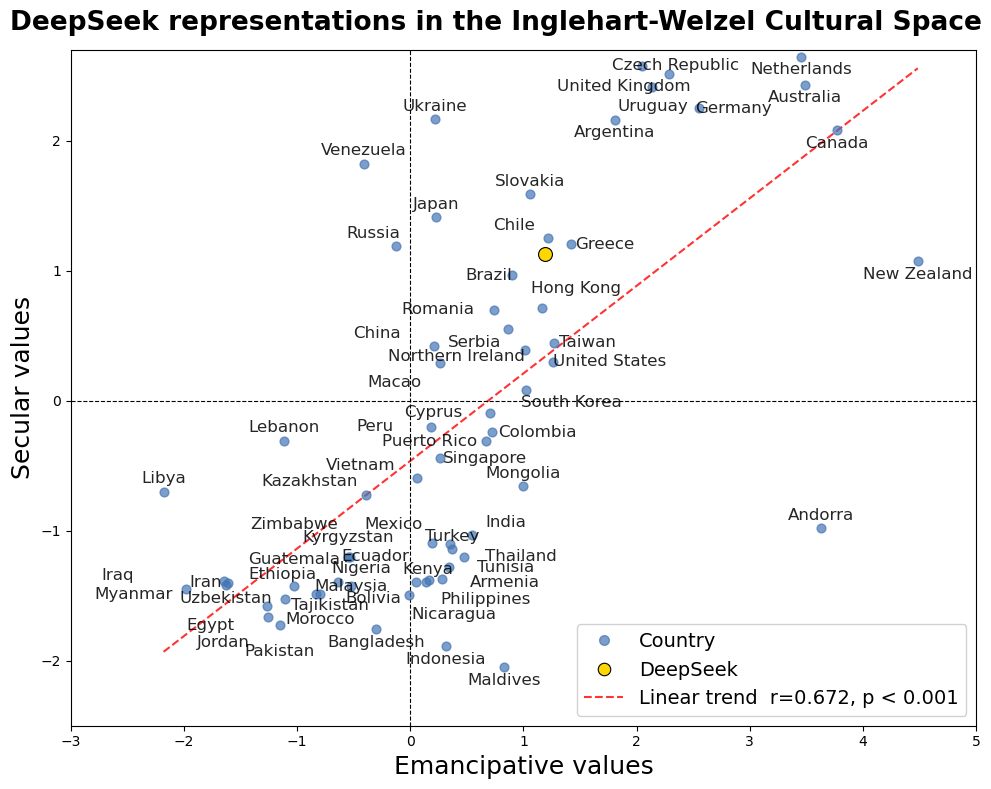

In [52]:
# adjust text locations to avoid overlap

forced_deepseek = {
    "Andorra": (0.0, 0.1),
    "Argentina": (0.0, -0.1),
    "Armenia": (0.7, 0.0),
    "Australia": (0.0, -0.1),
    "Bangladesh": (0.0, -0.1),
    "Bolivia": (-0.6, -0.15),
    "Brazil": (-0.2, 0.0),
    "Canada": (0.0, -0.1),
    "Chile": (-0.3, 0.1),
    "China": (-0.5, 0.1),
    "Colombia": (0.4, 0.0),
    "Cyprus": (-0.5, 0.0),
    "Czech Republic": (0.3, 0.0),
    "Ecuador": (-0.5, -0.10),
    "Egypt": (-0.5, -0.15),
    "Ethiopia": (-0.3, 0.15),
    "Germany": (0.3, 0.0),
    "Greece": (0.3, 0.0),
    "Guatemala": (0.0, 0.2),
    "Hong Kong": (0.3, 0.15),
    "India": (0.3, 0.1),
    "Indonesia": (0.0, -0.1),
    "Iran": (-0.2, 0.0),
    "Iraq": (-0.6, 0.1),
    "Japan": (0.0, 0.1),
    "Jordan": (-0.4, -0.2),
    "Kazakhstan": (-0.5, 0.1),
    "Kenya": (0.1, 0.1),
    "Kyrgyzstan": (0.0, 0.15),
    "Lebanon": (0.0, 0.1),
    "Libya": (0.0, 0.1),
    "Macao": (-0.4, -0.15),
    "Malaysia": (0.0, 0.0),
    "Maldives": (0.0, -0.1),
    "Mexico": (-0.5, 0.15),
    "Mongolia": (0.0, 0.1),
    "Morocco": (0.0, -0.2),
    "Myanmar": (-0.8, -0.1),
    "Netherlands": (0.0, -0.1),
    "New Zealand": (0.0, -0.1),
    "Nicaragua": (0.4, -0.15),
    "Nigeria": (0.2, 0.1),
    "Northern Ireland": (-0.6, -0.05),
    "Pakistan": (0.0, -0.2),
    "Peru": (-0.5, 0.0),
    "Philippines": (0.5, -0.15),
    "Puerto Rico": (-0.5, 0.0),
    "Romania": (-0.5, 0.0),
    "Russia": (-0.2, 0.1),
    "Serbia": (-0.3, -0.1),
    "Singapore": (0.4, 0.0),
    "Slovakia": (0.0, 0.1),
    "South Korea": (0.4, -0.1),
    "Taiwan": (0.3, -0.0),
    "Tajikistan": (0.4, -0.05),
    "Thailand": (0.5, 0.0),
    "Tunisia": (0.5, -0.0),
    "Turkey": (0.0, 0.1),
    "Ukraine": (0.0, 0.1),
    "United Kingdom": (-0.4, -0.1),
    "United States": (0.5, 0.0),
    "Uruguay": (0.0, -0.15),
    "Uzbekistan": (0.0, -0.1),
    "Venezuela": (0.0, 0.1),
    "Vietnam": (-0.5, 0.1),
    "Zimbabwe": (-0.5, 0.25),
}

visualize_llm(forced_deepseek)


In [53]:
shift_df = get_shift(df_llm, df_avg)

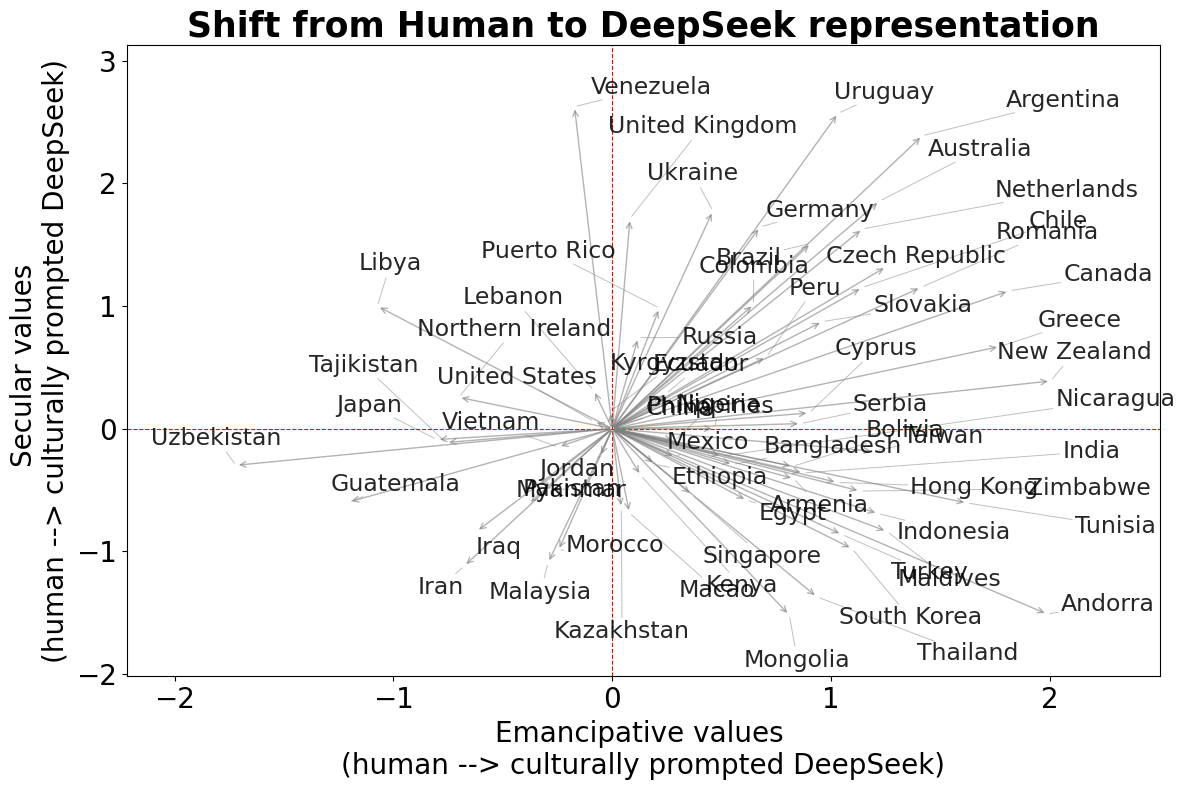

In [54]:
visualize_shift(shift_df)

/var/folders/c0/k3x4vq2s6gq08cgr4vmzcdz40000gp/T/ipykernel_57882/1564039379.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  zone_palette = plt.cm.get_cmap("tab20", len(zones))


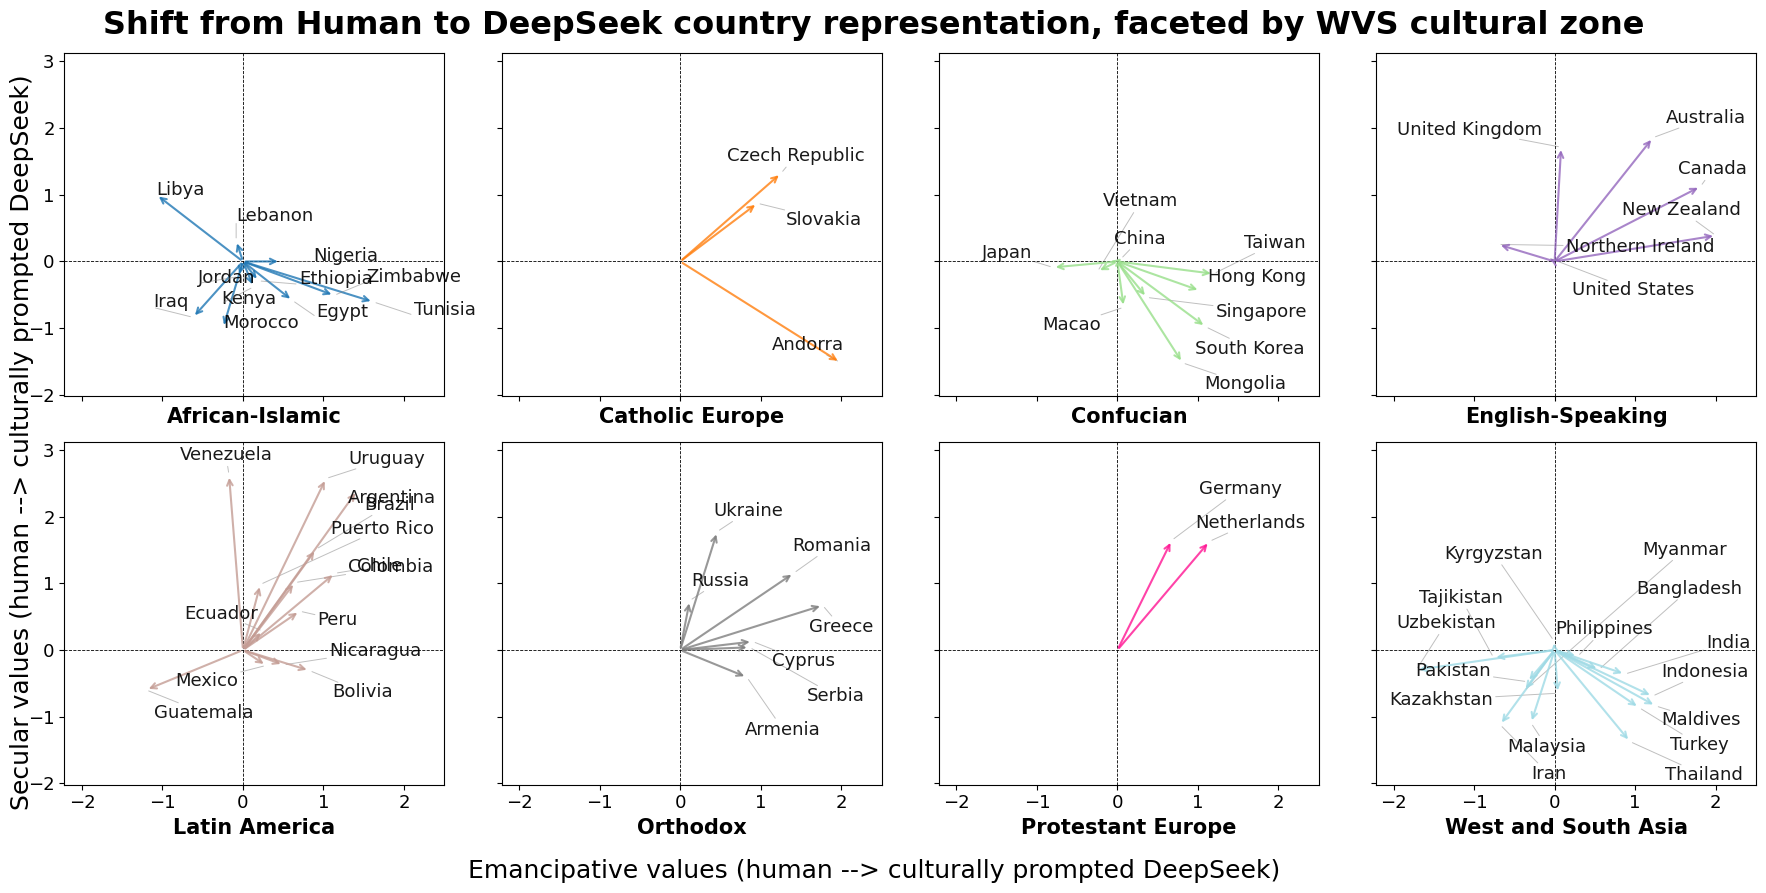

In [55]:
shift_df["cultural_zone"] = shift_df.index.map(country_to_zone)

zones = sorted(shift_df["cultural_zone"].unique())
zone_palette = plt.cm.get_cmap("tab20", len(zones))
zone_colors = {zone: zone_palette(i) for i, zone in enumerate(zones)}

visualize_cultural_facet()

In [56]:
one_sample_ttest_llm_default()

DeepSeek — TradAgg (1.133)
  Mean:-0.165, SD:1.408, t:-7.49, p:0.0

DeepSeek — SurvsAgg (1.186)
  Mean:0.441, SD:1.404, t:-4.312, p:0.0



In [57]:
paired_ttest()

DeepSeek — TradAgg
  Mean diff (after - before): 0.134, SD: 0.994
  t = 1.092, p = 0.279

DeepSeek — SurvsAgg
  Mean diff (after - before): 0.468, SD: 0.796
  t = 4.782, p = 0.000



In [58]:
paired_ttest_bydist()

DeepSeek — TradAgg
  Mean diff (after - before): -1.298, SD: 1.408
  t = -7.490, p = 0.000

DeepSeek — SurvsAgg
  Mean diff (after - before): -0.745, SD: 1.404
  t = -4.312, p = 0.000



-----------------------------------the end-----------------------------------